In [1]:
! gdown 1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW
! gdown 1-8TsrqTRFP-q9TM-6HinhO0ZVXFHq9TB
! gdown 1I9aPAvvYgQWdHGKtnd7IeTGXpx8vOm4h

Downloading...
From (original): https://drive.google.com/uc?id=1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW
From (redirected): https://drive.google.com/uc?id=1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW&confirm=t&uuid=e0644587-6406-44c4-91c7-95039783e0e9
To: /content/train_data.csv
100% 635M/635M [00:16<00:00, 38.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-8TsrqTRFP-q9TM-6HinhO0ZVXFHq9TB
To: /content/test_data.csv
100% 15.6M/15.6M [00:00<00:00, 99.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1I9aPAvvYgQWdHGKtnd7IeTGXpx8vOm4h
To: /content/title_brand.csv
100% 97.3M/97.3M [00:01<00:00, 85.4MB/s]


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")
product_df = pd.read_csv("title_brand.csv")

/tmp/ipykernel_2921/2058225489.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train_data.csv")


In [ ]:
print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Products:", product_df.shape)

train_df.head()

Train: (838944, 11)
Test : (20000, 10)
Products: (786445, 3)


,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


In [ ]:
train_df.isnull().sum()

,0
overall,0
vote,647476
verified,0
reviewTime,0
reviewerID,0
asin,0
style,348331
reviewerName,227
reviewText,0
summary,76


<div dir="rtl">
    <h2>سوال 2 </h2>
    <div>فرض کنید نظراتی که مقدار ستون overall آن‌ها ۴ یا ۵ است را همراه با حس مثبت، نظراتی که مقدارشان ۳ است را خنثی و نظراتی که مقدارشان ۱ یا ۲ است را حس منفی بدانیم. به‌ازای هر کدام از این سه دسته یک ابر کلمات (Word Cloud) رسم کنید تا بتوان کلمات پرتکرار هر دسته را مشاهده کرد. تا حد ممکن سعی کنید ابر کلمات به‌دست‌آمده شامل اطلاعات مفیدی باشد و کلمات زائد (Stop words) بین آن‌ها وجود نداشته باشد. آیا اشتراکی بین کلمات دسته‌ی مثبت و منفی وجود داشته است؟ چگونه آن‌ها را تفسیر می‌کنید؟
</div>
</div>

In [5]:
def sentiment_category(rating):
    if rating in [4, 5]:
        return "positive"
    elif rating == 3:
        return "neutral"
    elif rating in [1, 2]:
        return "negative"

train_df["sentiment"] = train_df["overall"].apply(sentiment_category)

train_df["sentiment"].value_counts()

,count
sentiment,
positive,617999
negative,139706
neutral,81239


In [6]:
import re
import nltk
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

custom_stopwords = {
    "product","amazon", "buy", "bought", "purchase", "purchased", "use", "used",
    "using", "get", "got", "one", "also", "would", "could",
    "really", "even", "still", "much", "thing", "things"}

stop_words.update(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    words = text.split()
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

In [9]:
positive_text = " ".join(
    train_df.loc[train_df["sentiment"] == "positive", "reviewText"]
    .dropna()
    .apply(clean_text)
)

neutral_text = " ".join(
    train_df.loc[train_df["sentiment"] == "neutral", "reviewText"]
    .dropna()
    .apply(clean_text)
)

negative_text = " ".join(
    train_df.loc[train_df["sentiment"] == "negative", "reviewText"]
    .dropna()
    .apply(clean_text)
)

In [10]:
def create_wordcloud(text, title):
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stop_words,
        max_words=100,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()

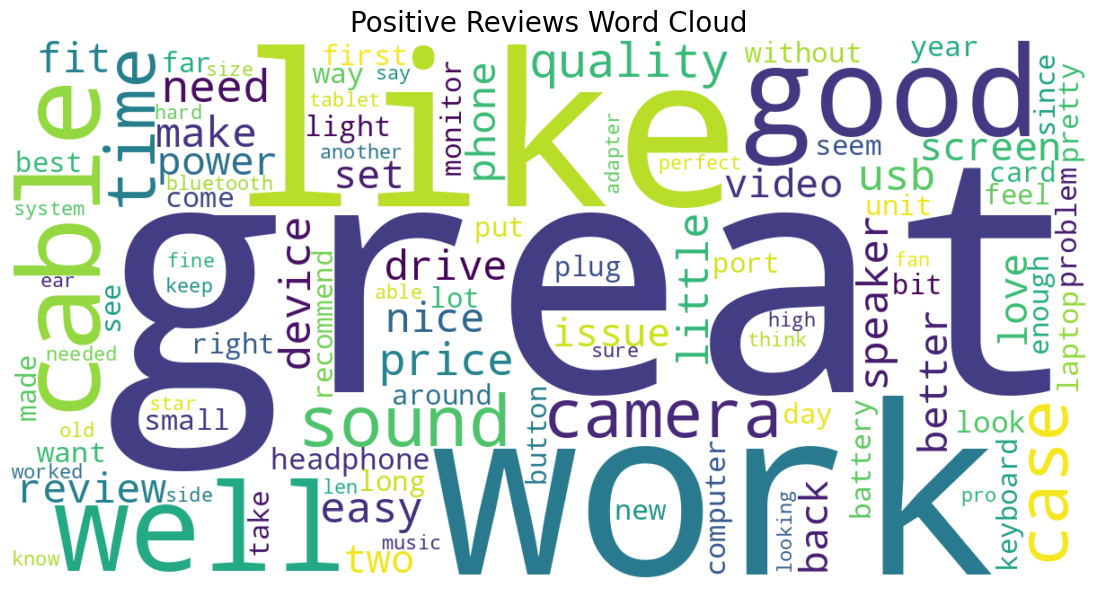

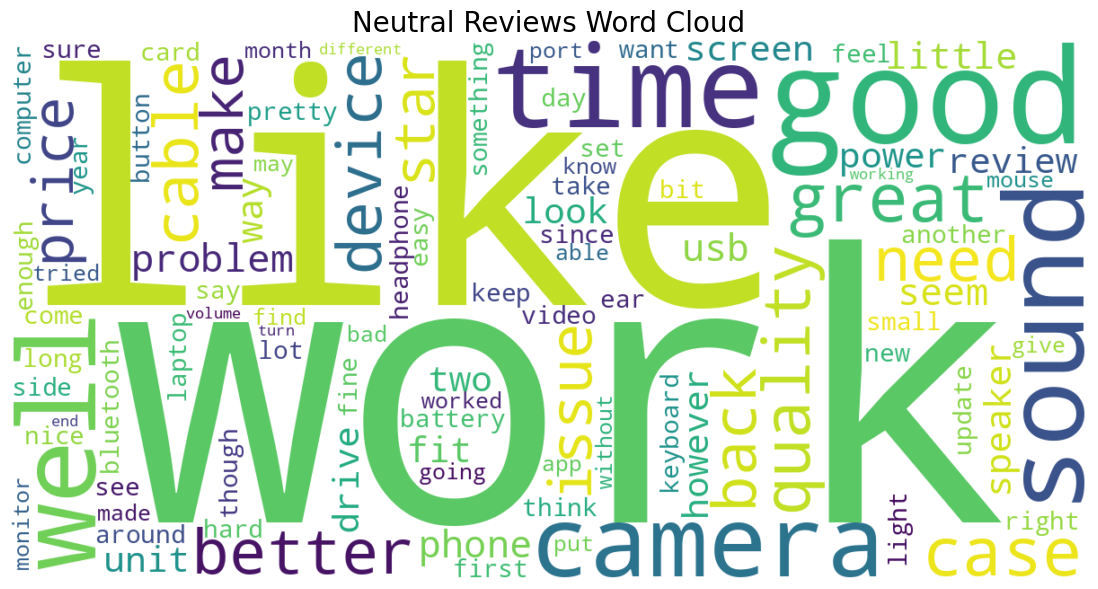

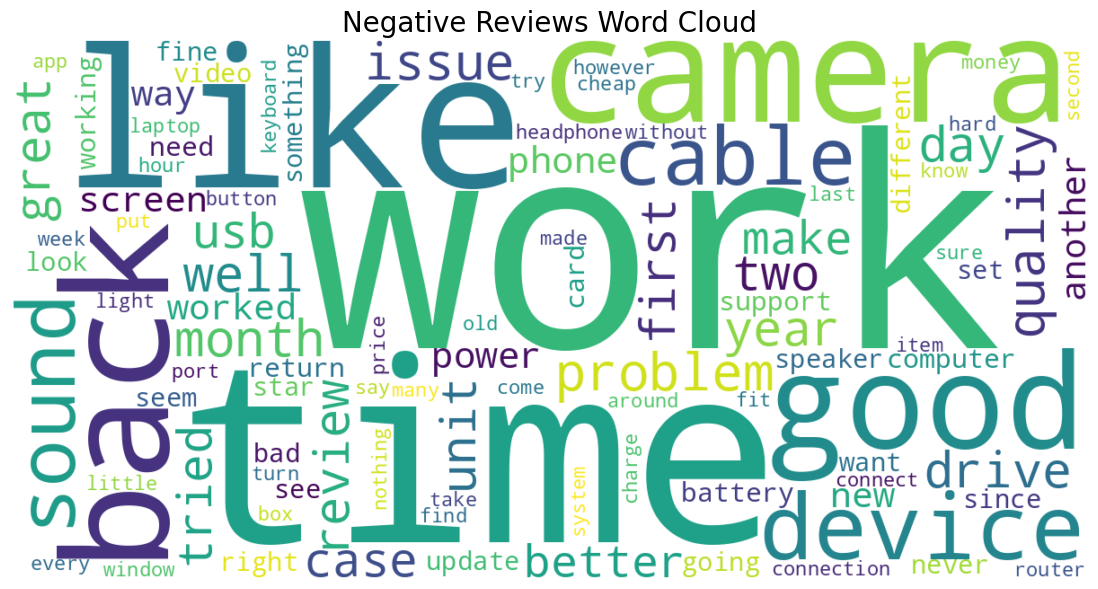

In [11]:
create_wordcloud(positive_text, "Positive Reviews Word Cloud")
create_wordcloud(neutral_text, "Neutral Reviews Word Cloud")
create_wordcloud(negative_text, "Negative Reviews Word Cloud")

In [12]:
from collections import Counter

positive_words = Counter(positive_text.split())
negative_words = Counter(negative_text.split())
neutral_words = Counter(neutral_text.split())
print("Positive:")
print(positive_words.most_common(30))

print("\nNeutral:")
print(neutral_words.most_common(30))

print("\nNegative:")
print(negative_words.most_common(30))
common_words = set(positive_words) & set(negative_words)

common_words_sorted = sorted(
    common_words,
    key=lambda word: positive_words[word] + negative_words[word],
    reverse=True
)

print("Common words:")
print(common_words_sorted[:30])

Positive:
[('great', 286504), ('like', 225091), ('good', 219909), ('well', 209171), ('works', 157432), ('case', 148265), ('sound', 147328), ('quality', 146075), ('cable', 131579), ('price', 128449), ('time', 127217), ('work', 125049), ('camera', 123025), ('easy', 118773), ('usb', 116902), ('little', 116369), ('need', 107168), ('nice', 103741), ('better', 96710), ('power', 94156), ('back', 88979), ('two', 86196), ('love', 84095), ('phone', 81966), ('set', 81783), ('screen', 81696), ('battery', 79884), ('small', 78530), ('first', 75228), ('new', 75131)]

Neutral:
[('good', 32513), ('like', 32466), ('work', 26041), ('well', 23175), ('sound', 21600), ('great', 21378), ('time', 20322), ('quality', 19700), ('case', 19182), ('works', 18989), ('camera', 18675), ('better', 17879), ('back', 16423), ('price', 14603), ('usb', 13675), ('cable', 13244), ('little', 13135), ('need', 12923), ('two', 12638), ('way', 12577), ('device', 12518), ('phone', 12171), ('however', 12132), ('power', 11986), ('scr

<div dir="rtl">با بررسی ابر کلمات نظرات مثبت، خنثی و منفی مشخص شد که تعدادی از کلمات مانند `quality`، `sound`، `camera`، `battery`، `cable`، `screen` و `phone` در هر دو گروه مثبت و منفی تکرار شده‌اند. این اشتراک نشان می‌دهد که کاربران در نظرات مثبت و منفی اغلب درباره ویژگی‌ها و جنبه‌های مشابهی از محصولات صحبت کرده‌اند، اما ارزیابی آنها از این ویژگی‌ها متفاوت بوده است.

برای مثال، کلمه `battery` ممکن است در یک نظر مثبت در جمله‌ای مانند «باتری عملکرد خوبی دارد» و در یک نظر منفی در جمله‌ای مانند «باتری بعد از مدتی از کار افتاد» ظاهر شود. بنابراین صرفاً مشاهده یک کلمه مشترک نمی‌تواند مثبت یا منفی بودن نظر را مشخص کند و باید کلمات و زمینه اطراف آن نیز در نظر گرفته شوند.

در نظرات منفی، کلماتی مانند `problem`، `tried`، `months` و `working` بیشتر نمایانگر مشکلات و تجربه‌های نامطلوب کاربران هستند. در مقابل، در نظرات مثبت کلماتی مانند `great`، `good`، `love`، `nice`، `easy` و `better` بیشتر دیده می‌شوند که نشان‌دهنده ارزیابی مثبت کاربران از محصولات یا ویژگی‌های آنها هستند.

در مجموع، اشتراک میان کلمات مثبت و منفی بیشتر به دلیل تمرکز کاربران بر موضوعات و ویژگی‌های مشترک محصولات است، نه یکسان بودن احساس آنها. تفاوت اصلی در نحوه توصیف و ارزیابی این ویژگی‌ها مشاهده می‌شود.
</div>